## Load and prepare final dataframe for model

In [1]:
# Load df_artists and df_songs from CSV with all columns visible in head/sample output.

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

df_artists = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists.csv')

print(df_artists.shape)

# Load df_songs from CSV.

df_songs = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_songs.csv')

print(df_songs.shape)

(13655, 44)
(38383, 43)


In [21]:
df_artists.head()

,name,musicbrainz_artist_id,musicbrainz_mbid,spotify_id,performer_pre_normalized,first_top_20_hit_year,first_charting_song_year,last_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,first_song_year,years_active_on_charts,first_charting_song_position,first_charting_song_duration,top_20_hit_song_#_wks_on_chart_any_position,genre_tags_musicbrainz,first_year_on_chart_songs,genre_tags_through_first_top_10_hit,major_genre_categories_through_first_top_10_hit,#_of_major_genre_categories_through_first_top_10_hit,musicbrainz_major_genre_categories,musicbrainz_#_of_genres,spotify_genres,spotify_major_genre_categories,combined_major_genre_categories,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker
0,!!! (chk chk chk),NaN,NaN,NaN,!!! (Chk Chk Chk),NaN,NaN,NaN,NaN,NaN,NaN,2007-2007,0,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"""groove"" holmes",NaN,NaN,NaN,"""Groove"" Holmes",NaN,1966.0,1966.0,NaN,NaN,1966.0,1966-1966,44,11,NaN,NaN,1966.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"""little"" jimmy dickens",NaN,NaN,NaN,"""Little"" Jimmy Dickens",1965.0,1965.0,1965.0,1.0,1.0,1965.0,1965-1965,15,10,NaN,NaN,1965.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,"""pookie"" hudson",232958.0,29dc9009-015f-47c4-bd17-ed2af6d2ae0c,NaN,"""Pookie"" Hudson",NaN,1963.0,1963.0,NaN,NaN,1963.0,1963-1963,96,1,NaN,NaN,1963.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"""weird al"" yankovic",NaN,NaN,NaN,"""Weird Al"" Yankovic",1984.0,1983.0,2014.0,2.0,4.0,1983.0,1983-2014,63,8,NaN,NaN,1983.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [2]:
# Create df_artists_final from df_artists:
# - drops non-feature/identifier columns
# - filters to artists whose first top-20 hit was between 2000 and 2019
# - keeps combined_major_genre_categories, renamed to combined_major_genre_categories_artist

cols_to_drop = [
    'musicbrainz_artist_id', 'musicbrainz_mbid', 'spotify_id',
    'performer_pre_normalized', 'last_charting_song_year', 'first_song_year',
    'years_active_on_charts', 'first_charting_song_position',
    'first_charting_song_duration', 'genre_tags_musicbrainz',
    'first_year_on_chart_songs', 'genre_tags_through_first_top_10_hit',
    'major_genre_categories_through_first_top_10_hit',
    '#_of_major_genre_categories_through_first_top_10_hit',
    'musicbrainz_major_genre_categories', 'musicbrainz_#_of_genres',
    'spotify_genres', 'spotify_major_genre_categories',
]

df_artists_final = (
    df_artists[df_artists['first_top_20_hit_year'].between(2000, 2019)]
    .drop(columns=[c for c in cols_to_drop if c in df_artists.columns])
    .rename(columns={'combined_major_genre_categories': 'combined_major_genre_categories_artist'})
    .reset_index(drop=True)
)

print(df_artists_final.shape)
df_artists_final.head()


(778, 26)


,name,first_top_20_hit_year,first_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,combined_major_genre_categories_artist,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker
0,2 chainz,2012.0,2012.0,1.0,9.0,27.0,Hip Hop/Rap,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006764,5314.363492,0.010130,1.510211e-01,7104.5,1.0
1,21 savage,2017.0,2016.0,2.0,15.0,41.0,Hip Hop/Rap,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002871,5233.436039,0.001326,7.977090e-02,3116.5,1.0
2,3 doors down,2000.0,2000.0,1.0,2.0,53.0,"Metal, Pop, Rock","Blues, Metal, Rock",233933.0,0.00664,0.545,0.865,0.000011,0.168,-5.708,0.0286,99.009,0.543,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0
3,3oh!3,2008.0,2008.0,1.0,1.0,37.0,"Electronic/Dance, Hip Hop/Rap, Pop, Punk/Hardc...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,5 seconds of summer,2014.0,2014.0,1.0,6.0,20.0,"Pop, Punk/Hardcore",Pop,237248.0,0.02830,0.572,0.499,0.000000,0.213,-5.237,0.0311,101.593,0.108,1.0,0.0,0.000048,1.000000,0.000000,1.555431e-18,NaN,1.0


#### *Don't run both of the next 2 cells. Choose one. The first cell one-hot-encodes the artist genre data and the second cell one-hot-encodes the song genre data. The former has fewer null values.*

In [3]:
# One-hot encode combined_major_genre_categories_artist into binary columns in df_artists_final.
# Splits comma-separated genre strings, creates one binary column per genre,
# prefixed with 'artist_genre_', replacing the original column.

artist_genre_dummies = (
    df_artists_final['combined_major_genre_categories_artist']
    .fillna('')
    .str.split(', ')
    .explode()
    .str.strip()
    .pipe(lambda s: pd.get_dummies(s, prefix='artist_genre'))
    .groupby(level=0)
    .max()
)

# Remove the empty-string column if it exists (from NaN rows)
artist_genre_dummies = artist_genre_dummies.loc[:, artist_genre_dummies.columns != 'artist_genre_']

# Insert genre columns where combined_major_genre_categories_artist was, then drop original
insert_at = df_artists_final.columns.get_loc('combined_major_genre_categories_artist')
df_artists_final = pd.concat([
    df_artists_final.iloc[:, :insert_at],
    artist_genre_dummies,
    df_artists_final.iloc[:, insert_at + 1:]
], axis=1)

# Add binary flag for artists with no genre data — inserted after last genre column
all_genre_cols = [c for c in df_artists_final.columns if c.startswith(('artist_genre_', 'song_genre_'))]
last_genre_idx = df_artists_final.columns.get_loc(all_genre_cols[-1])
df_artists_final.insert(last_genre_idx + 1, 'artist_genre_unknown', (df_artists_final[all_genre_cols].sum(axis=1) == 0).astype(int))

print("Artist genre columns added:", artist_genre_dummies.columns.tolist())
print("df_artists_final shape:", df_artists_final.shape)


Artist genre columns added: ['artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music']
df_artists_final shape: (778, 44)


In [ ]:
# One-hot encode first_top_20_song_major_genres into binary columns in df_artists_final.
# Splits comma-separated genre strings, creates one binary column per genre,
# prefixed with 'song_genre_', replacing the original column.
# Also adds song_genre_unknown flag for artists with no song genre data.

song_genre_dummies = (
    df_artists_final['first_top_20_song_major_genres']
    .fillna('')
    .str.split(', ')
    .explode()
    .str.strip()
    .pipe(lambda s: pd.get_dummies(s, prefix='song_genre'))
    .groupby(level=0)
    .max()
)

# Remove the empty-string column if it exists (from NaN rows)
song_genre_dummies = song_genre_dummies.loc[:, song_genre_dummies.columns != 'song_genre_']

# Add song_genre_unknown flag to dummies before inserting
song_genre_dummies['song_genre_unknown'] = (song_genre_dummies.sum(axis=1) == 0).astype(int)

# Insert genre columns where first_top_20_song_major_genres was, then drop original
insert_at = df_artists_final.columns.get_loc('first_top_20_song_major_genres')
df_artists_final = pd.concat([
    df_artists_final.iloc[:, :insert_at],
    song_genre_dummies,
    df_artists_final.iloc[:, insert_at + 1:]
], axis=1)

print("Song genre columns added:", song_genre_dummies.columns.tolist())
print("df_artists_final shape:", df_artists_final.shape)


In [4]:
# Drop rows with null top_20_hitmaker (artists with no verified top-20 songs)
# and any duplicate rows, then confirm shape and class balance.

df_artists_final = (
    df_artists_final
    .dropna(subset=['top_20_hitmaker'])
    .drop_duplicates()
    .reset_index(drop=True)
)

print(df_artists_final.shape)
print()
print(df_artists_final['top_20_hitmaker'].value_counts())


(759, 44)

top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64


In [5]:
# Drop name column, cast bool genre columns to int (0/1) in df_artists_final.

genre_cols = [c for c in df_artists_final.columns if c.startswith('genre_')]

df_artists_final = df_artists_final.drop(columns=['name'])
df_artists_final[genre_cols] = df_artists_final[genre_cols].astype(int)

print(df_artists_final.shape)
print(df_artists_final[genre_cols].dtypes.unique())


(759, 43)
[]


#### *Check this next cell for decisions regarding null values*

In [6]:
# Impute missing values in df_artists_final:
# - Network metrics → fill with 0 (no collaboration data = no centrality)
# - Weeks on chart and Spotify audio features → left as-is (nulls preserved)

network_metric_cols = [
    'degree_centrality', 'harmonic_closeness', 'betweenness_centrality',
    'eigenvector_centrality', 'power'
]
for col in network_metric_cols:
    if col in df_artists_final.columns:
        df_artists_final[col] = df_artists_final[col].fillna(0)

print("Imputation complete.")
print(df_artists_final.isnull().sum()[df_artists_final.isnull().sum() > 0])


Imputation complete.
top_20_hit_song_#_wks_on_chart_any_position      87
first_top_20_song_major_genres                  391
first_top_20_song_duration_ms                   326
first_top_20_song_acousticness                  326
first_top_20_song_danceability                  326
first_top_20_song_energy                        326
first_top_20_song_instrumentalness              326
first_top_20_song_liveness                      326
first_top_20_song_loudness                      326
first_top_20_song_speechiness                   326
first_top_20_song_tempo                         326
first_top_20_song_valence                       326
first_top_20_song_mode                          326
first_top_20_song_explicit                      326
degree_centrality_top20_rolling5                206
harmonic_closeness_centrality_top20_rolling5    206
betweenness_centrality_top20_rolling5           206
eigenvector_centrality_top20_rolling5           206
power_of_connected_artists_top20_rolling5  

In [7]:
# Fill null network metric columns with 0 (no collaboration data = no centrality)
network_cols = [
    'degree_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
    'betweenness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
    'power_of_connected_artists_top20_rolling5',
]
df_artists_final[network_cols] = df_artists_final[network_cols].fillna(0)
print(df_artists_final[network_cols].isnull().sum())


degree_centrality_top20_rolling5                0
harmonic_closeness_centrality_top20_rolling5    0
betweenness_centrality_top20_rolling5           0
eigenvector_centrality_top20_rolling5           0
power_of_connected_artists_top20_rolling5       0
dtype: int64


In [9]:
# Fill null network metric columns with 0 (no collaboration data = no centrality)
# degree_centrality and power dropped — not used in model
network_cols = [
    'harmonic_closeness_centrality_top20_rolling5',
    'betweenness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
]
df_artists_final = df_artists_final.drop(columns=[
    'degree_centrality_top20_rolling5',
    'power_of_connected_artists_top20_rolling5',
])
df_artists_final[network_cols] = df_artists_final[network_cols].fillna(0)
print(df_artists_final[network_cols].isnull().sum())


harmonic_closeness_centrality_top20_rolling5    0
betweenness_centrality_top20_rolling5           0
eigenvector_centrality_top20_rolling5           0
dtype: int64


In [10]:
df_artists_final.head()

,first_top_20_hit_year,first_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,artist_genre_Blues,artist_genre_Classical,artist_genre_Country/Americana,artist_genre_Easy Listening/Vocal,artist_genre_Electronic/Dance,artist_genre_Experimental/Avant-Garde,artist_genre_Folk,artist_genre_Gospel/Christian/Religious,artist_genre_Hip Hop/Rap,artist_genre_Jazz,artist_genre_Latin,artist_genre_Metal,artist_genre_Pop,artist_genre_Punk/Hardcore,artist_genre_R&B/Soul/Funk,artist_genre_Reggae/Caribbean,artist_genre_Rock,artist_genre_World Music,artist_genre_unknown,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,top_20_hitmaker
0,2012.0,2012.0,1.0,9.0,27.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5314.363492,0.010130,1.510211e-01,1.0
1,2017.0,2016.0,2.0,15.0,41.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5233.436039,0.001326,7.977090e-02,1.0
2,2000.0,2000.0,1.0,2.0,53.0,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,0,"Blues, Metal, Rock",233933.0,0.00664,0.545,0.865,0.000011,0.168,-5.708,0.0286,99.009,0.543,0.0,0.0,0.000000,0.000000,0.000000e+00,1.0
3,2008.0,2008.0,1.0,1.0,37.0,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,True,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000e+00,1.0
4,2014.0,2014.0,1.0,6.0,20.0,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,0,Pop,237248.0,0.02830,0.572,0.499,0.000000,0.213,-5.237,0.0311,101.593,0.108,1.0,0.0,1.000000,0.000000,1.555431e-18,1.0


## Model

In [11]:
# This will change based on whether you use artist genre info or song genre info

# Drop columns not used as model features
cols_to_drop = ['first_top_20_song_major_genres', 'first_top_20_hit_year', 'first_charting_song_year']
df_artists_final = df_artists_final.drop(columns=[c for c in cols_to_drop if c in df_artists_final.columns])
print(df_artists_final.shape)


(759, 38)


In [12]:
# Separate features and target
X = df_artists_final.drop(columns=['top_20_hitmaker'])
y = df_artists_final['top_20_hitmaker']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny value counts:\n{y.value_counts()}")
print(f"\ny class balance:\n{y.value_counts(normalize=True).round(3)}")


X shape: (759, 37)
y shape: (759,)

y value counts:
top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64

y class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64


In [13]:
# Split into train and test sets, stratified to preserve class balance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (607, 37), Test: (152, 37)

Train class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64

Test class balance:
top_20_hitmaker
0.0    0.566
1.0    0.434
Name: proportion, dtype: float64


In [14]:
# Scale features for models sensitive to feature magnitude (Logistic Regression, SVM)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")


Scaling complete.
X_train_scaled shape: (607, 37)


In [15]:
# Evaluate models using 5-fold cross-validation on training set only.
# Test holdout is reserved for final evaluation after hyperparameter tuning.
# return_train_score=True enables overfitting check (train score vs CV score gap).

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier
import numpy as np

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

models = {
    'Dummy':   (DummyClassifier(strategy='stratified', random_state=42), X_train),
    'XGBoost': (XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'), X_train),
}

results = []
for name, (model, X_tr) in models.items():
    cv = cross_validate(model, X_tr, y_train, cv=5, scoring=scoring, return_train_score=True)
    results.append({
        'Model':             name,
        'Accuracy':          cv['test_accuracy'].mean(),
        'Precision':         cv['test_precision'].mean(),
        'Recall':            cv['test_recall'].mean(),
        'F1':                cv['test_f1'].mean(),
        'ROC-AUC (CV)':      cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)':   cv['train_roc_auc'].mean(),
        'Overfit Gap':       cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
    })

df_results = pd.DataFrame(results).set_index('Model').round(3)
print(df_results)


         Accuracy  Precision  Recall     F1  ROC-AUC (CV)  ROC-AUC (Train)  \
Model                                                                        
Dummy       0.503      0.421   0.405  0.413         0.491            0.490   
XGBoost     0.672      0.626   0.599  0.612         0.697            0.998   

         Overfit Gap  
Model                 
Dummy         -0.001  
XGBoost        0.301  


#### XGBoost had severe overfitting. One of the potential causes for this is too many features. In the next cell we identify low-value features.

artist_genre_Country/Americana                  2.33
#_of_charting_songs_through_first_top_20_hit    2.32
artist_genre_Pop                                1.88
artist_genre_Hip Hop/Rap                        1.60
first_top_20_song_explicit                      1.40
first_top_20_song_instrumentalness              1.36
first_top_20_song_danceability                  1.06
artist_genre_Metal                              1.03
artist_genre_unknown                            1.02
first_top_20_song_loudness                      0.95
eigenvector_centrality_top20_rolling5           0.85
first_top_20_song_speechiness                   0.84
years_through_first_top_20_hit                  0.84
betweenness_centrality_top20_rolling5           0.80
first_top_20_song_valence                       0.78
first_top_20_song_duration_ms                   0.76
first_top_20_song_liveness                      0.74
first_top_20_song_tempo                         0.73
top_20_hit_song_#_wks_on_chart_any_position   

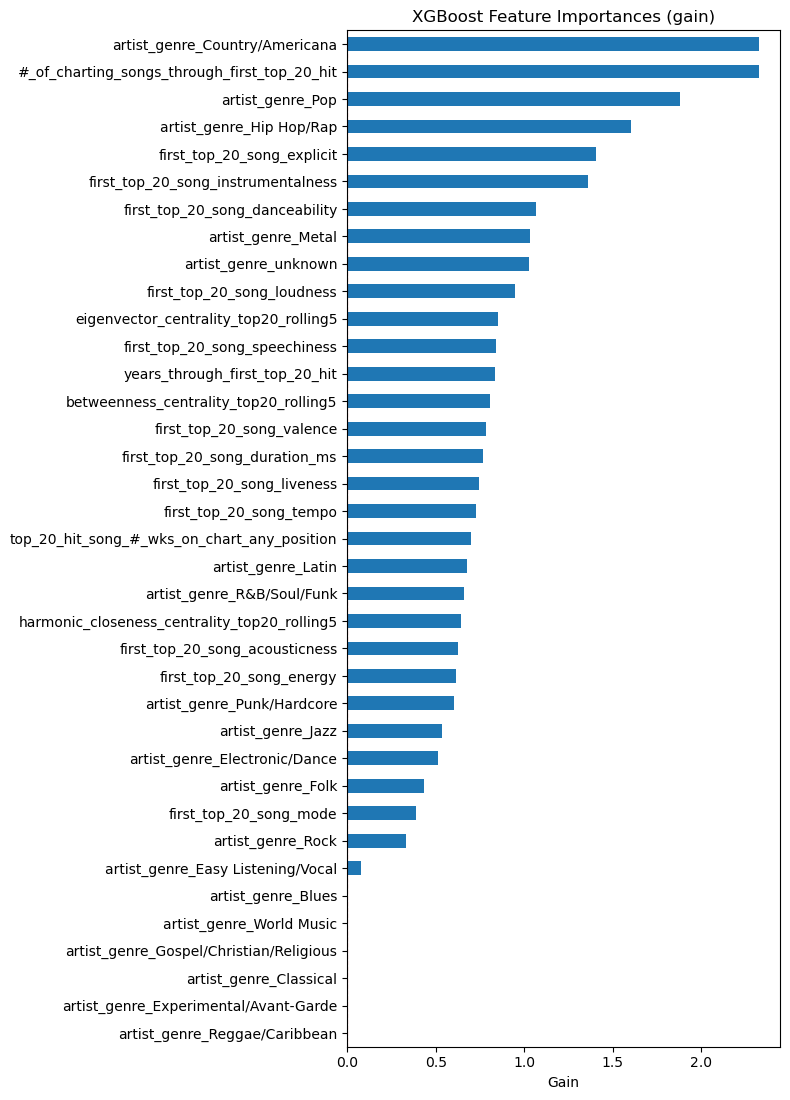

In [17]:
# Fit XGBoost on training set and display feature importances (gain-based).
# Prints full ranked table for review and plots a bar chart.

import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

xgb_inspect = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_inspect.fit(X_train, y_train)

importances = pd.Series(
    xgb_inspect.get_booster().get_score(importance_type='gain'),
    name='gain'
).reindex(X_train.columns, fill_value=0).sort_values(ascending=False)

print(importances.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, max(4, len(importances) * 0.3)))
importances.sort_values().plot.barh(ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_title('XGBoost Feature Importances (gain)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()


In [18]:
# Drop zero-importance and near-zero-importance features identified from XGBoost gain scores.
# Also drops first_top_20_song_mode (low gain, weak signal).

cols_to_drop = [
    'artist_genre_Experimental/Avant-Garde',
    'artist_genre_Classical',
    'artist_genre_Blues',
    'artist_genre_World Music',
    'artist_genre_Gospel/Christian/Religious',
    'artist_genre_Reggae/Caribbean',
    'artist_genre_Easy Listening/Vocal',
    'first_top_20_song_mode',
]

cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} features. Remaining: {X_train.shape[1]}")
print(X_train.columns.tolist())


Dropped 8 features. Remaining: 29
['years_through_first_top_20_hit', '#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Country/Americana', 'artist_genre_Electronic/Dance', 'artist_genre_Folk', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Rock', 'artist_genre_unknown', 'first_top_20_song_duration_ms', 'first_top_20_song_acousticness', 'first_top_20_song_danceability', 'first_top_20_song_energy', 'first_top_20_song_instrumentalness', 'first_top_20_song_liveness', 'first_top_20_song_loudness', 'first_top_20_song_speechiness', 'first_top_20_song_tempo', 'first_top_20_song_valence', 'first_top_20_song_explicit', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5']


#### Re-running CV comparison after dropping low importance features:

In [19]:
# Re-evaluate Dummy and XGBoost with 5-fold CV after feature reduction.
# Checks whether dropping low-importance features reduced the overfit gap.

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

models = {
    'Dummy':   (DummyClassifier(strategy='stratified', random_state=42), X_train),
    'XGBoost': (XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'), X_train),
}

results = []
for name, (model, X_tr) in models.items():
    cv = cross_validate(model, X_tr, y_train, cv=5, scoring=scoring, return_train_score=True)
    results.append({
        'Model':             name,
        'Accuracy':          cv['test_accuracy'].mean(),
        'Precision':         cv['test_precision'].mean(),
        'Recall':            cv['test_recall'].mean(),
        'F1':                cv['test_f1'].mean(),
        'ROC-AUC (CV)':      cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)':   cv['train_roc_auc'].mean(),
        'Overfit Gap':       cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
    })

df_results = pd.DataFrame(results).set_index('Model').round(3)
print(df_results)


         Accuracy  Precision  Recall     F1  ROC-AUC (CV)  ROC-AUC (Train)  \
Model                                                                        
Dummy       0.503      0.421   0.405  0.413         0.491            0.490   
XGBoost     0.659      0.614   0.561  0.586         0.690            0.998   

         Overfit Gap  
Model                 
Dummy         -0.001  
XGBoost        0.308  


#### Still overfitting the same as before. Now trying regularization tuning.

In [21]:
# Test heavily regularized XGBoost to reduce overfitting before full tuning.
# Shallow trees, high min_child_weight, subsampling, and L1/L2 penalties.

from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

xgb_reg = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=2,
    reg_lambda=5,
    random_state=42,
    eval_metric='logloss',
)

cv = cross_validate(xgb_reg, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)
print(f"ROC-AUC (CV):    {cv['test_roc_auc'].mean():.3f}")
print(f"ROC-AUC (Train): {cv['train_roc_auc'].mean():.3f}")
print(f"Overfit Gap:     {cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean():.3f}")


ROC-AUC (CV):    0.738
ROC-AUC (Train): 0.881
Overfit Gap:     0.143


In [22]:
# Hyperparameter tuning for regularized XGBoost using RandomizedSearchCV on training set only.
# Optimizes ROC-AUC with 5-fold CV. Test holdout remains untouched.

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from scipy.stats import uniform, randint
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

param_grid = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(2, 5),
    'learning_rate':     uniform(0.01, 0.1),
    'min_child_weight':  randint(5, 20),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.5, 0.5),
    'reg_alpha':         uniform(1, 5),
    'reg_lambda':        uniform(3, 7),
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC: {search.best_score_:.3f}")
print(f"Best params: {search.best_params_}")

# Check overfit gap on best model
cv = cross_validate(search.best_estimator_, X_train, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
print(f"\nROC-AUC (CV):    {cv['test_score'].mean():.3f}")
print(f"ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best CV ROC-AUC: 0.747
Best params: {'colsample_bytree': np.float64(0.6584610025781388), 'learning_rate': np.float64(0.026949274668609247), 'max_depth': 2, 'min_child_weight': 14, 'n_estimators': 322, 'reg_alpha': np.float64(5.221065703631557), 'reg_lambda': np.float64(9.510117843675822), 'subsample': np.float64(0.6281664523398175)}

ROC-AUC (CV):    0.747
ROC-AUC (Train): 0.812
Overfit Gap:     0.065


ROC-AUC (Test):  0.764
ROC-AUC (CV):    0.747

              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74        86
         1.0       0.66      0.62      0.64        66

    accuracy                           0.70       152
   macro avg       0.69      0.69      0.69       152
weighted avg       0.70      0.70      0.70       152



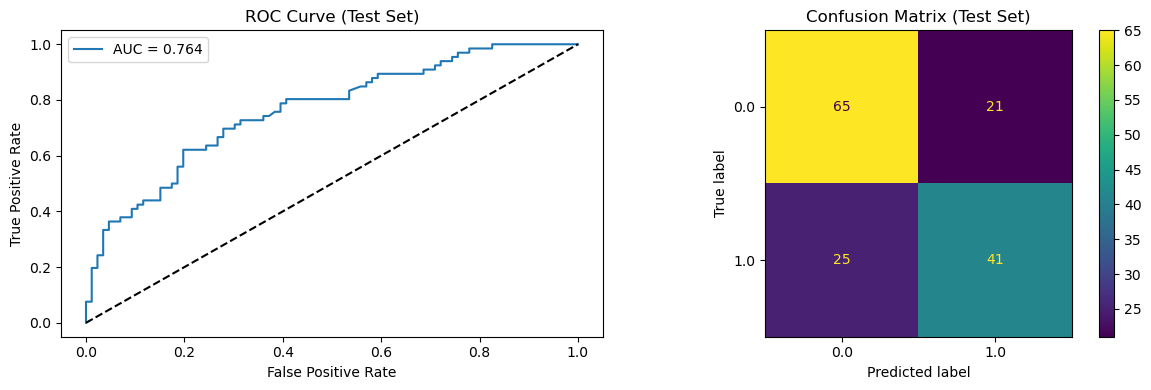

In [23]:
# Evaluate tuned XGBoost on held-out test set.
# Reports classification metrics and plots ROC curve and confusion matrix.

from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print(f"ROC-AUC (Test):  {roc_auc_score(y_test, y_prob):.3f}")
print(f"ROC-AUC (CV):    {search.best_score_:.3f}")
print()
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Test Set)')
axes[0].legend()

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1])
axes[1].set_title('Confusion Matrix (Test Set)')

plt.tight_layout()
plt.show()


Feature importance (mean absolute SHAP):
#_of_charting_songs_through_first_top_20_hit    0.5199
betweenness_centrality_top20_rolling5           0.2366
artist_genre_Pop                                0.1855
eigenvector_centrality_top20_rolling5           0.1644
artist_genre_Hip Hop/Rap                        0.1342
top_20_hit_song_#_wks_on_chart_any_position     0.1123
first_top_20_song_instrumentalness              0.0495
first_top_20_song_speechiness                   0.0433
first_top_20_song_danceability                  0.0404
harmonic_closeness_centrality_top20_rolling5    0.0403
first_top_20_song_valence                       0.0350
first_top_20_song_liveness                      0.0342
artist_genre_R&B/Soul/Funk                      0.0327
first_top_20_song_tempo                         0.0311
years_through_first_top_20_hit                  0.0302
first_top_20_song_loudness                      0.0294
first_top_20_song_acousticness                  0.0136
first_top_20_song_energy

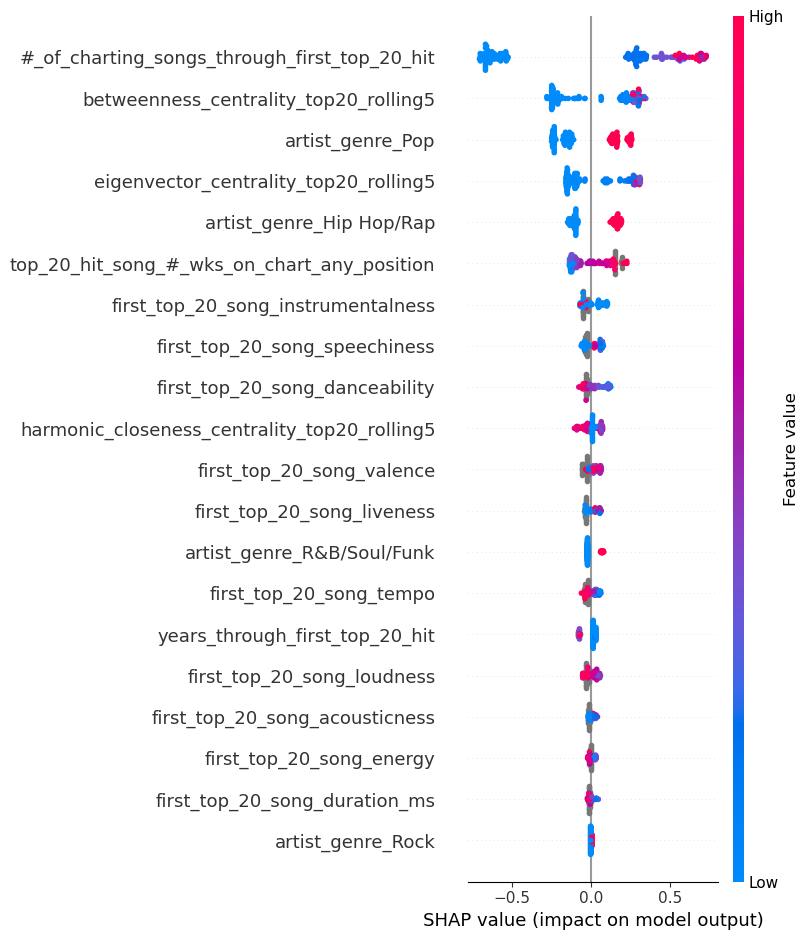

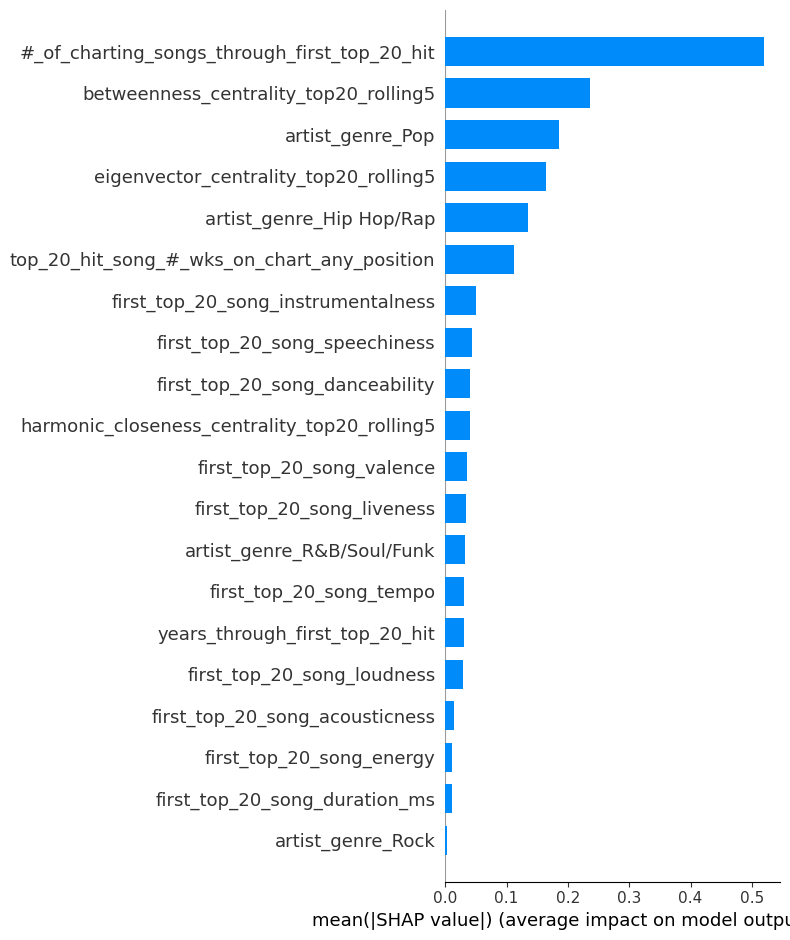

In [25]:
# SHAP analysis of tuned XGBoost model.
# Summary plot shows overall feature importance and direction of effect.
# Also prints mean absolute SHAP values ranked by importance.

import shap
import pandas as pd

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Printed importance ranking
mean_abs_shap = pd.Series(
    shap_values.__abs__().mean(axis=0),
    index=X_test.columns,
    name='mean_abs_shap'
).sort_values(ascending=False)

print("Feature importance (mean absolute SHAP):")
print(mean_abs_shap.round(4).to_string())

# Beeswarm plot
shap.summary_plot(shap_values, X_test, plot_type='dot', show=True)

# Bar plot
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)


#### Now examining how the previous model performs compared to a pared-down version of that model with only the top 7 features.

In [26]:
# Subset features to top SHAP contributors plus instrumentalness.
# Rerun 5-fold CV to compare against full-feature benchmark (ROC-AUC 0.747, gap 0.065).

from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier

top_features = [
    '#_of_charting_songs_through_first_top_20_hit',
    'betweenness_centrality_top20_rolling5',
    'artist_genre_Pop',
    'eigenvector_centrality_top20_rolling5',
    'artist_genre_Hip Hop/Rap',
    'top_20_hit_song_#_wks_on_chart_any_position',
    'first_top_20_song_instrumentalness',
]

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

cv = cross_validate(
    search.best_estimator_, X_train_top, y_train,
    cv=5, scoring='roc_auc', return_train_score=True
)

print(f"ROC-AUC (CV):    {cv['test_score'].mean():.3f}  (benchmark: 0.747)")
print(f"ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}  (benchmark: 0.065)")


ROC-AUC (CV):    0.751  (benchmark: 0.747)
ROC-AUC (Train): 0.793
Overfit Gap:     0.042  (benchmark: 0.065)


In [27]:
# Retune XGBoost hyperparameters on reduced 7-feature set.
# Previous best params were found on 29 features — retuning may improve further.

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from scipy.stats import uniform, randint
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

param_grid = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(2, 5),
    'learning_rate':     uniform(0.01, 0.1),
    'min_child_weight':  randint(5, 20),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.5, 0.5),
    'reg_alpha':         uniform(1, 5),
    'reg_lambda':        uniform(3, 7),
}

search_top = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
search_top.fit(X_train_top, y_train)

print(f"\nBest CV ROC-AUC: {search_top.best_score_:.3f}")
print(f"Best params: {search_top.best_params_}")

cv = cross_validate(search_top.best_estimator_, X_train_top, y_train,
                    cv=5, scoring='roc_auc', return_train_score=True)
print(f"\nROC-AUC (CV):    {cv['test_score'].mean():.3f}")
print(f"ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best CV ROC-AUC: 0.752
Best params: {'colsample_bytree': np.float64(0.5550259622638384), 'learning_rate': np.float64(0.03279351625419417), 'max_depth': 3, 'min_child_weight': 13, 'n_estimators': 215, 'reg_alpha': np.float64(2.762844281670845), 'reg_lambda': np.float64(5.133468807106203), 'subsample': np.float64(0.6658623412571767)}

ROC-AUC (CV):    0.752
ROC-AUC (Train): 0.804
Overfit Gap:     0.052


── Test Set Comparison ──────────────────────────
                                29 features    7 features
ROC-AUC (Test)                        0.764         0.754
ROC-AUC (CV)                          0.747         0.752
Overfit Gap (CV)                      0.065         0.052

              precision    recall  f1-score   support

         0.0       0.71      0.77      0.74        86
         1.0       0.66      0.59      0.62        66

    accuracy                           0.69       152
   macro avg       0.69      0.68      0.68       152
weighted avg       0.69      0.69      0.69       152



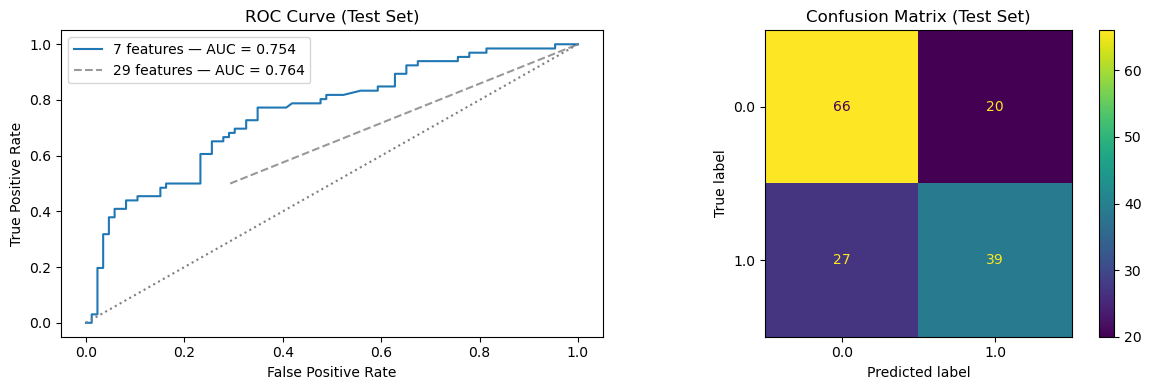

In [28]:
# Evaluate final tuned XGBoost (7-feature model) on held-out test set.
# Compares against previous 29-feature model (ROC-AUC 0.764).

from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

best_xgb_top = search_top.best_estimator_
y_pred = best_xgb_top.predict(X_test_top)
y_prob = best_xgb_top.predict_proba(X_test_top)[:, 1]

test_auc = roc_auc_score(y_test, y_prob)
prev_test_auc = 0.764

print("── Test Set Comparison ──────────────────────────")
print(f"{'':30s} {'29 features':>12}  {'7 features':>12}")
print(f"{'ROC-AUC (Test)':30s} {'0.764':>12}  {test_auc:>12.3f}")
print(f"{'ROC-AUC (CV)':30s} {'0.747':>12}  {search_top.best_score_:>12.3f}")
print(f"{'Overfit Gap (CV)':30s} {'0.065':>12}  {'0.052':>12}")
print()
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, label=f'7 features — AUC = {test_auc:.3f}')
axes[0].plot([0.293, 1], [0.5, 1], 'k--', label='29 features — AUC = 0.764', alpha=0.4)
axes[0].plot([0, 1], [0, 1], 'grey', linestyle=':')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Test Set)')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1])
axes[1].set_title('Confusion Matrix (Test Set)')

plt.tight_layout()
plt.show()


Feature importance (mean absolute SHAP):
#_of_charting_songs_through_first_top_20_hit    0.4884
betweenness_centrality_top20_rolling5           0.2741
artist_genre_Pop                                0.2492
artist_genre_Hip Hop/Rap                        0.1972
first_top_20_song_instrumentalness              0.1818
eigenvector_centrality_top20_rolling5           0.1750
top_20_hit_song_#_wks_on_chart_any_position     0.1461


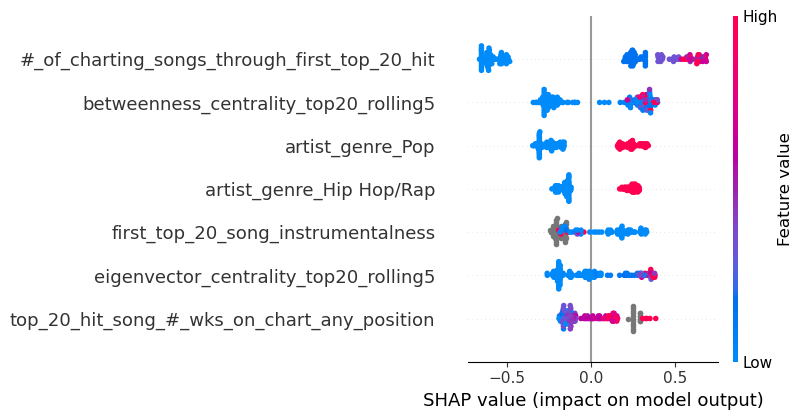

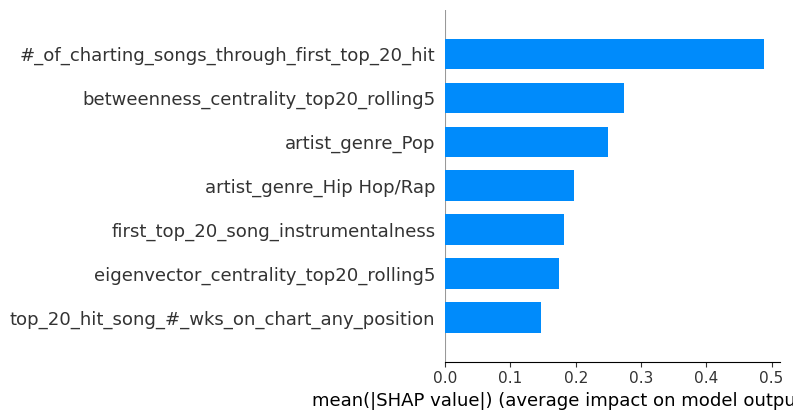

In [29]:
# SHAP analysis of final 7-feature XGBoost model.
# Prints mean absolute SHAP values and plots beeswarm and bar charts.

import shap
import pandas as pd

explainer_top = shap.TreeExplainer(best_xgb_top)
shap_values_top = explainer_top.shap_values(X_test_top)

# Printed importance ranking
mean_abs_shap = pd.Series(
    shap_values_top.__abs__().mean(axis=0),
    index=X_test_top.columns,
    name='mean_abs_shap'
).sort_values(ascending=False)

print("Feature importance (mean absolute SHAP):")
print(mean_abs_shap.round(4).to_string())

# Beeswarm plot
shap.summary_plot(shap_values_top, X_test_top, plot_type='dot', show=True)

# Bar plot
shap.summary_plot(shap_values_top, X_test_top, plot_type='bar', show=True)
